In [43]:
import numpy as np
import matplotlib.pyplot as plt

%precision 3
%matplotlib inline

In [44]:
from scipy import integrate
import warnings

warnings.filterwarnings('ignore', category=integrate.IntegrationWarning)

In [45]:
x_range = np.array([0, 1])

In [46]:
def f(x):
    if x_range[0] <= x <= x_range[1]:
        return 2 * x
    else:
        return 0

In [47]:
X = [x_range, f]

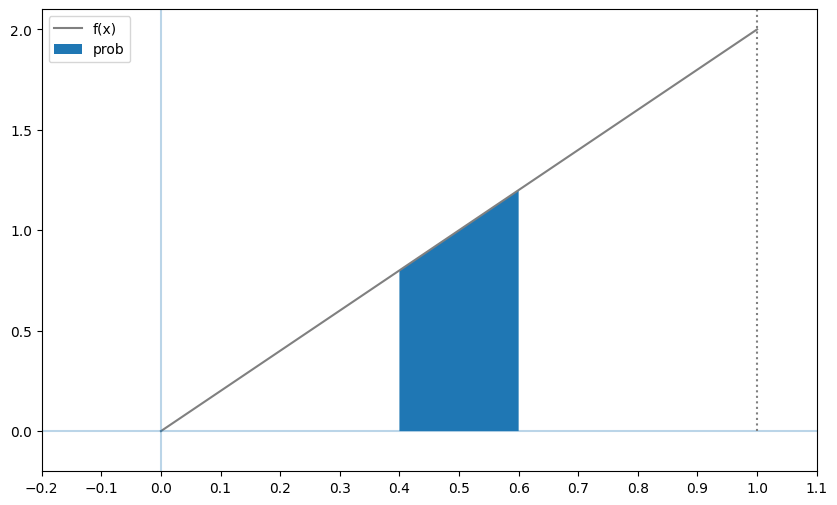

In [48]:
xs = np.linspace(x_range[0], x_range[1], 100)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [f(x) for x in xs], label='f(x)', color='gray')
ax.hlines(0, -0.2, 1.2, alpha=0.3)
ax.vlines(0, -0.2, 2.2, alpha=0.3)
ax.vlines(xs.max(), 0, 2.2, linestyles=':', color='gray')

xs = np.linspace(0.4, 0.6, 100)
ax.fill_between(xs, [f(x) for x in xs], label='prob')
ax.set_xticks(np.arange(-0.2, 1.3, 0.1))
ax.set_xlim(-0.2, 1.1)
ax.set_ylim(-0.2, 2.1)
ax.legend()

plt.show()

In [49]:
integrate.quad(f, 0.4, 0.6)

(0.200, 0.000)

In [50]:
from scipy.optimize import minimize_scalar

res = minimize_scalar(f)

res.fun

np.int64(0)

In [51]:
integrate.quad(f, -np.inf, np.inf)

(1.000, 0.000)

In [52]:
def F(x):
    return integrate.quad(f, -np.inf, x)[0]

In [53]:
F(0.6) - F(0.4)

0.200

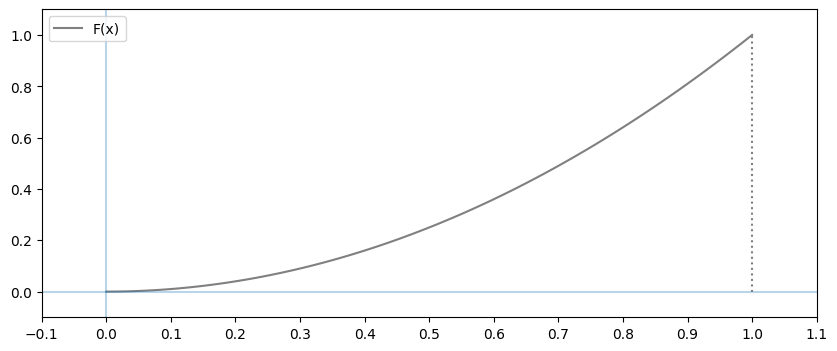

In [54]:
xs = np.linspace(x_range[0], x_range[1], 100)

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.plot(xs, [F(x) for x in xs], label='F(x)', color='gray')
ax.hlines(0, -0.1, 1.1, alpha=0.3)
ax.vlines(0, -0.1, 1.1, alpha=0.3)
ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')

ax.set_xticks(np.arange(-0.1, 1.2, 0.1))
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()


In [55]:
y_range = [3, 5]

def g(y):
    if y_range[0] <= y <= y_range[1]:
        return (y - 3) / 2
    else:
        return 0
    
def G(y):
    return integrate.quad(g, -np.inf, y)[0]

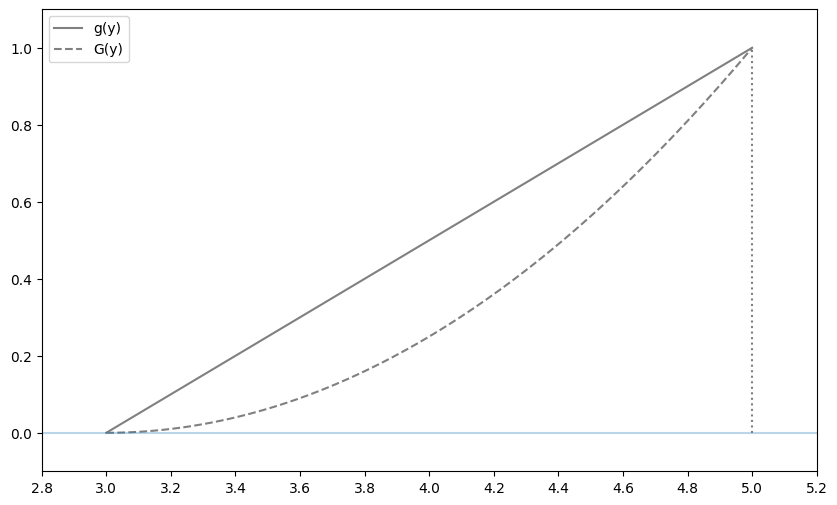

In [56]:
ys = np.linspace(y_range[0], y_range[1], 100)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(ys, [g(y) for y in ys], label='g(y)', color='gray')
ax.plot(ys, [G(y) for y in ys], label='G(y)', color='gray', linestyle='--')
ax.hlines(0, 2.8, 5.2, alpha=0.3)
ax.vlines(ys.max(), 0, 1, linestyles=':', color='gray')

ax.set_xticks(np.arange(2.8, 5.2, 0.2))
ax.set_xlim(2.8, 5.2)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()


In [57]:
def integrand(x):
    return x * f(x)

integrate.quad(integrand, -np.inf, np.inf)[0]

0.667

In [58]:
def E(X, g=lambda x: x):
    def integrand(x):
        return g(x) * f(x)
    
    return integrate.quad(integrand, -np.inf, np.inf)[0]

In [59]:
E(X)

0.667

In [60]:
E(X, g=lambda x: 2 * x + 3)

4.333

In [61]:
2 * E(X) + 3

4.333

In [62]:
mean = E(X)

def integrand(x):
    return (x - mean) ** 2 * f(x)

integrate.quad(integrand, -np.inf, np.inf)[0]

0.056

In [63]:
def V(X, g=lambda x: x):
    x_range, f = X
    mean = E(X, g)
    def integrand(x):
        return (g(x) - mean) ** 2 * f(x)
    
    return integrate.quad(integrand, -np.inf, np.inf)[0]

In [64]:
V(X)

0.056

In [65]:
V(X, lambda x: 2 * x + 3)



0.222

In [66]:
2 ** 2 * V(X)

0.222

In [67]:
x_range = [0, 2]
y_range = [0, 1]

In [72]:
def f_xy(x, y):
    if 0 <= y <= 1 and 0 <= x - y <= 1:
        return 4 * y * (x - y)
    else:
        return 0

In [73]:
XY = [x_range, y_range, f_xy]

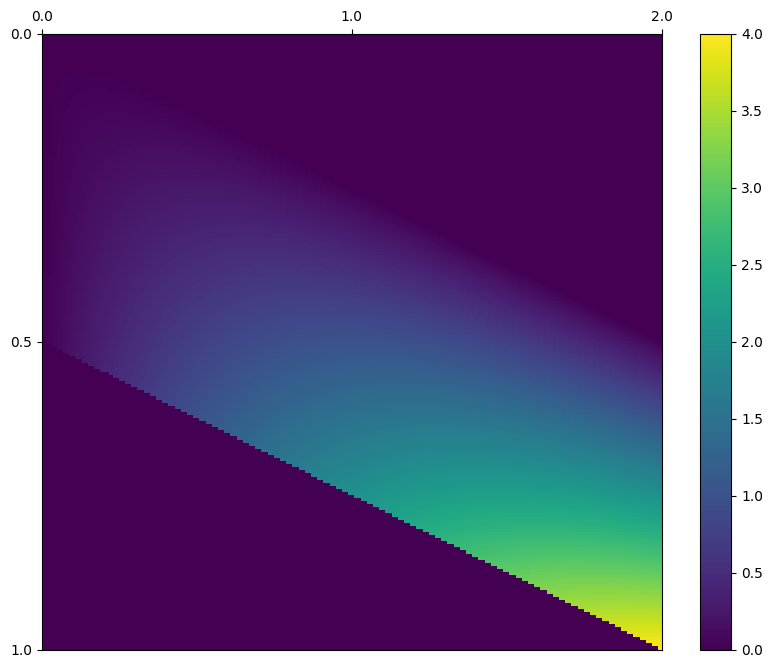

In [74]:
xs = np.linspace(x_range[0], x_range[1], 200)
ys = np.linspace(y_range[0], y_range[1], 200)
pd = np.array([[f_xy(x, y) for y in ys] for x in xs])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

c = ax.pcolor(pd)
ax.set_xticks(np.linspace(0, 200, 3), minor=False)
ax.set_yticks(np.linspace(0, 200, 3), minor=False)
ax.set_xticklabels(np.linspace(0, 2, 3))
ax.set_yticklabels(np.linspace(0, 1, 3))
ax.invert_yaxis()
ax.xaxis.tick_top()
fig.colorbar(c, ax=ax)

plt.show()


In [75]:
integrate.nquad(f_xy, [[-np.inf, np.inf], [-np.inf, np.inf]])[0]

1.000

In [79]:
from functools import partial

def f_X(x):
    return integrate.quad(partial(f_xy, x), -np.inf, np.inf)[0]
def f_Y(y):
    return integrate.quad(partial(f_xy, y=y), -np.inf, np.inf)[0]

In [81]:
X = [x_range, f_X]
Y = [y_range, f_Y]

/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36794 (\N{CJK UNIFIED IDEOGRAPH-8FBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

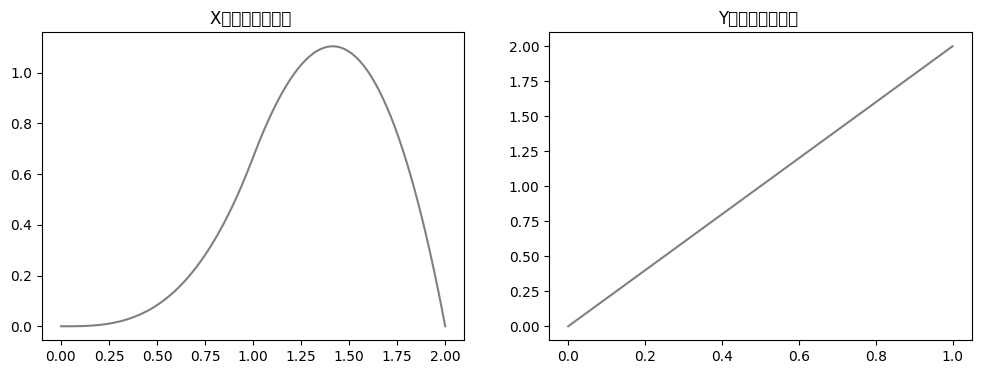

In [82]:
xs = np.linspace(*x_range, 100)
ys = np.linspace(*y_range, 100)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.plot(xs, [f_X(x) for x in xs], color='gray')
ax2.plot(ys, [f_Y(y) for y in ys], color='gray')
ax1.set_title('Xの周辺密度関数 ')
ax2.set_title('Yの周辺密度関数 ')

plt.show()

In [83]:
def integrand(x, y):
    return x * f_xy(x, y)

integrate.nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])[0]

1.333

In [84]:
def E(XY, g):
    x_range, y_range, f_xy = XY
    def integrand(x, y):
        return g(x, y) * f_xy(x, y)
    
    return integrate.nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])[0]

In [85]:
mean_X = E(XY, lambda x, y: x)
mean_X

1.333

In [87]:
mean_Y = E(XY, lambda x, y: y)
mean_Y

0.667

In [88]:
a, b = 2, 3

In [89]:
E(XY, lambda x, y: a * x + b * y)


4.667

In [90]:
a * mean_X + b * mean_Y

4.667

In [91]:
def integrand(x, y):
    return (x - mean_X) ** 2 * f_xy(x, y)

integrate.nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])[0]

0.111

In [92]:
def V(XY, g):
    x_range, y_range, f_xy = XY
    mean = E(XY, g)
    def integrand(x, y):
        return (g(x, y) - mean) ** 2 * f_xy(x, y)
    
    return integrate.nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])[0]

In [93]:
var_X = V(XY, lambda x, y: x)
var_X

0.111

In [94]:
var_Y = V(XY, lambda x, y: y)
var_Y

0.056

In [95]:
def Cov(XY):
    x_range, y_range, f_xy = XY
    mean_X = E(XY, lambda x, y: x)
    mean_Y = E(XY, lambda x, y: y)
    
    def integrand(x, y):
        return (x - mean_X) * (y - mean_Y) * f_xy(x, y)
    
    return integrate.nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])[0]

In [96]:
cov_xy = Cov(XY)
cov_xy

0.056

In [97]:
V(XY, lambda x, y: a * x + b * y)

1.611

In [98]:
a ** 2 * var_X + b ** 2 * var_Y + 2 * a * b * cov_xy

1.611

In [99]:
cov_xy / np.sqrt(var_X * var_Y)


0.707